# Air Quality Health Risk Predictor Model

## Importing the Dependencies

In [3]:
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Model serialization
import pickle

## Loading the Datasets

In [4]:
df = pd.read_csv("/content/air_quality_health_impact_data.csv")


In [5]:
## First 5 columns
df.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


In [6]:
# Last 5 columns
df.tail()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
5806,5807,171.112762,11.246387,197.984628,158.643107,17.743678,280.370909,37.359323,61.707640,4.097129,14,5,2,100.000000,4.0
5807,5808,490.691667,275.340762,55.774170,132.336871,29.334724,108.043492,34.532542,21.528555,6.682549,8,6,2,100.000000,3.0
5808,5809,314.841798,41.892699,184.708551,82.105823,68.334578,105.568503,22.975564,92.725625,2.889698,12,2,3,100.000000,1.0
5809,5810,208.080473,165.533785,199.177255,100.796385,87.586488,166.469537,36.090620,25.836286,10.722393,6,2,3,100.000000,4.0
5810,5811,83.269257,82.216262,119.968244,193.440691,79.849177,28.681885,18.239090,77.096194,16.410320,14,2,2,81.668298,0.0


In [7]:
# Column Names
df.columns

Index(['RecordID', 'AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3', 'Temperature',
       'Humidity', 'WindSpeed', 'RespiratoryCases', 'CardiovascularCases',
       'HospitalAdmissions', 'HealthImpactScore', 'HealthImpactClass'],
      dtype='object')

In [8]:
# Shape of dataset
df.shape

(5811, 15)

## Understanding the Dataset

In [9]:
## Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RecordID             5811 non-null   int64  
 1   AQI                  5811 non-null   float64
 2   PM10                 5811 non-null   float64
 3   PM2_5                5811 non-null   float64
 4   NO2                  5811 non-null   float64
 5   SO2                  5811 non-null   float64
 6   O3                   5811 non-null   float64
 7   Temperature          5811 non-null   float64
 8   Humidity             5811 non-null   float64
 9   WindSpeed            5811 non-null   float64
 10  RespiratoryCases     5811 non-null   int64  
 11  CardiovascularCases  5811 non-null   int64  
 12  HospitalAdmissions   5811 non-null   int64  
 13  HealthImpactScore    5811 non-null   float64
 14  HealthImpactClass    5811 non-null   float64
dtypes: float64(11), int64(4)
memory usage:

In [10]:
## Statistical Information
df.describe()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
count,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000
mean,2906.000000,248.438476,148.654997,100.223714,102.293445,49.456838,149.312431,14.975500,54.776853,9.989177,9.974187,4.988986,2.001033,93.785223,0.281191
std,1677.635538,144.777638,85.698500,58.096612,57.713175,28.530329,86.534240,14.483067,26.020786,5.776950,3.129234,2.216791,1.398794,13.318904,0.714075
min,1.000000,0.005817,0.015848,0.031549,0.009625,0.011023,0.001661,-9.990998,10.001506,0.002094,1.000000,0.000000,0.000000,22.448488,0.000000
25%,1453.500000,122.951293,75.374954,49.435171,53.538538,24.887264,73.999665,2.481500,31.995262,4.952343,8.000000,3.000000,1.000000,98.203057,0.000000
50%,2906.000000,249.127841,147.634997,100.506337,102.987736,49.530165,149.559871,14.942428,54.543904,10.051742,10.000000,5.000000,2.000000,100.000000,0.000000
75%,4358.500000,373.630668,222.436759,151.340260,151.658516,73.346617,223.380126,27.465374,77.641639,14.971840,12.000000,6.000000,3.000000,100.000000,0.000000
max,5811.000000,499.858837,299.901962,199.984965,199.980195,99.969561,299.936812,39.963434,99.997493,19.999139,23.000000,14.000000,12.000000,100.000000,4.000000


In [11]:
## Check datatypes
df.dtypes

,0
RecordID,int64
AQI,float64
PM10,float64
PM2_5,float64
NO2,float64
SO2,float64
O3,float64
Temperature,float64
Humidity,float64
WindSpeed,float64


In [12]:
## Missing Values
df.isnull().sum()

,0
RecordID,0
AQI,0
PM10,0
PM2_5,0
NO2,0
SO2,0
O3,0
Temperature,0
Humidity,0
WindSpeed,0


In [13]:
## Missing Values
df.duplicated().sum()

np.int64(0)

## EDA and Feature Engineering

### Visualizations

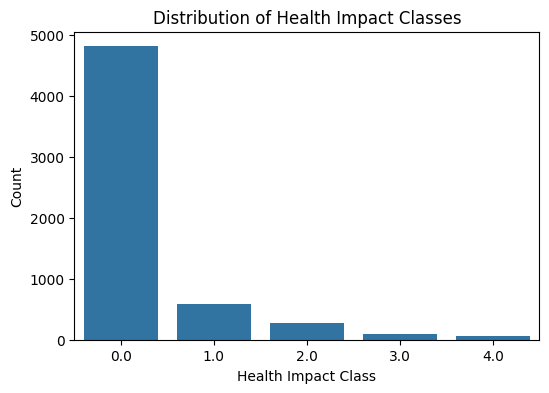

In [14]:
# Distribution of the target variable
plt.figure(figsize=(6,4))
sns.countplot(x='HealthImpactClass', data=df)

plt.title('Distribution of Health Impact Classes')
plt.xlabel('Health Impact Class')
plt.ylabel('Count')

plt.show()

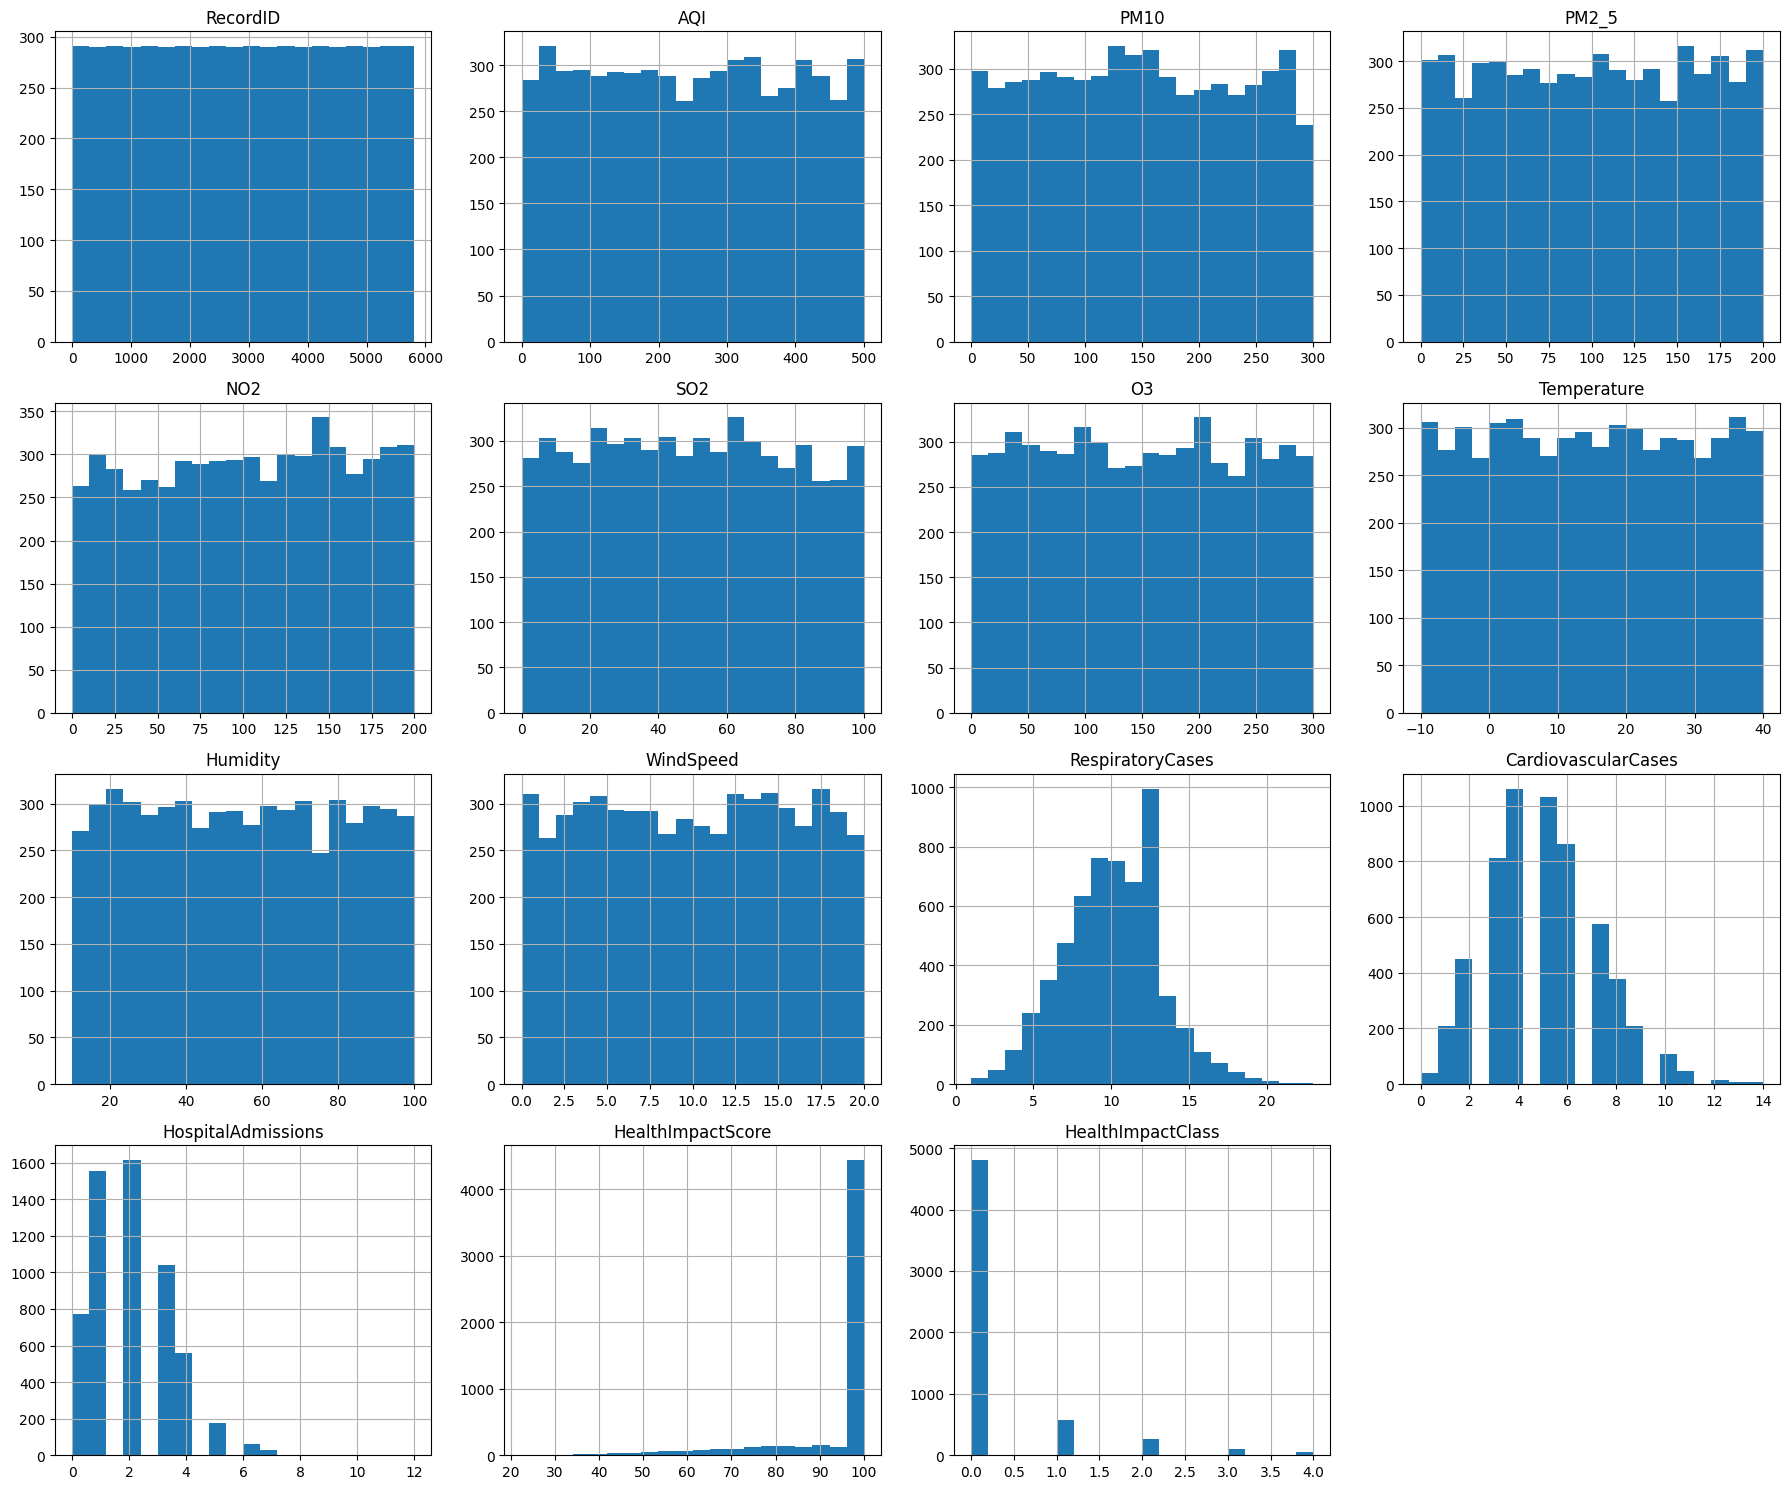

In [15]:
# Plot histograms for all numerical columns
df.hist(figsize=(18,15), bins=20)

plt.tight_layout()
plt.show()


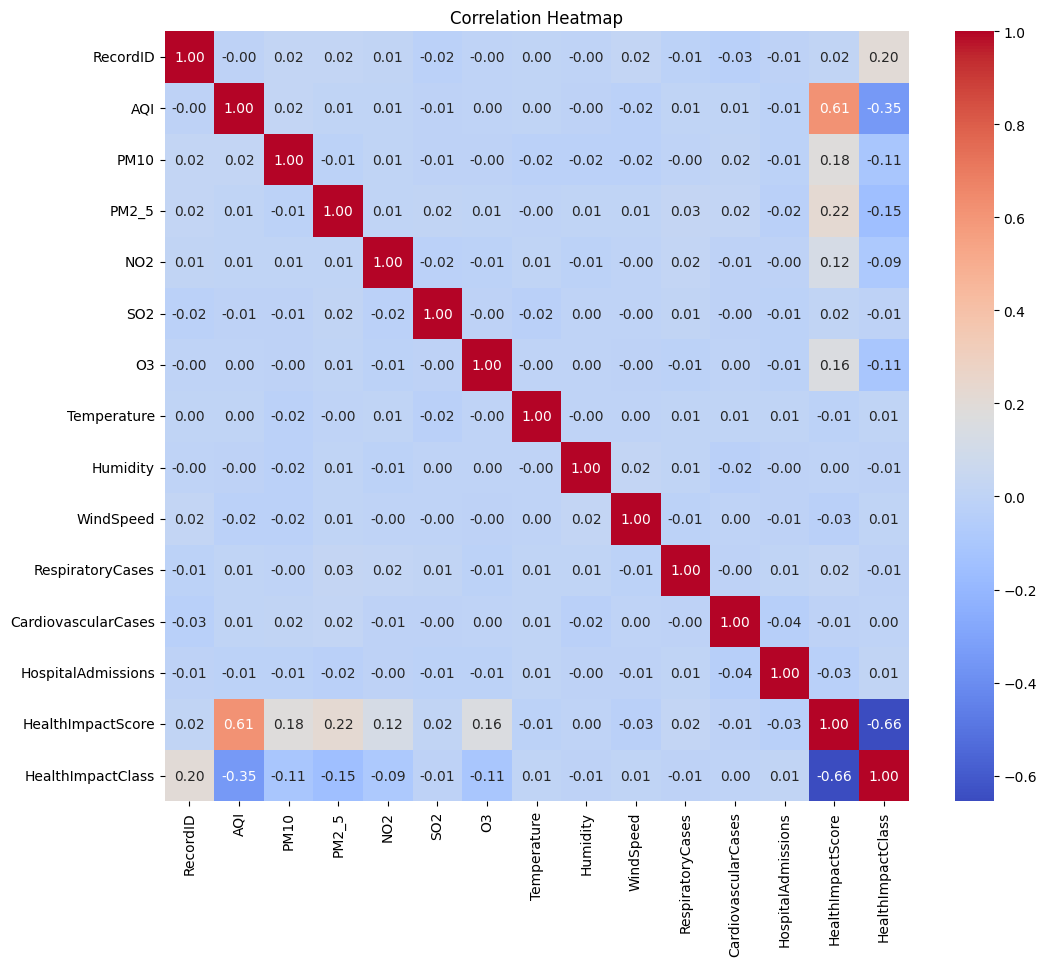

In [16]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

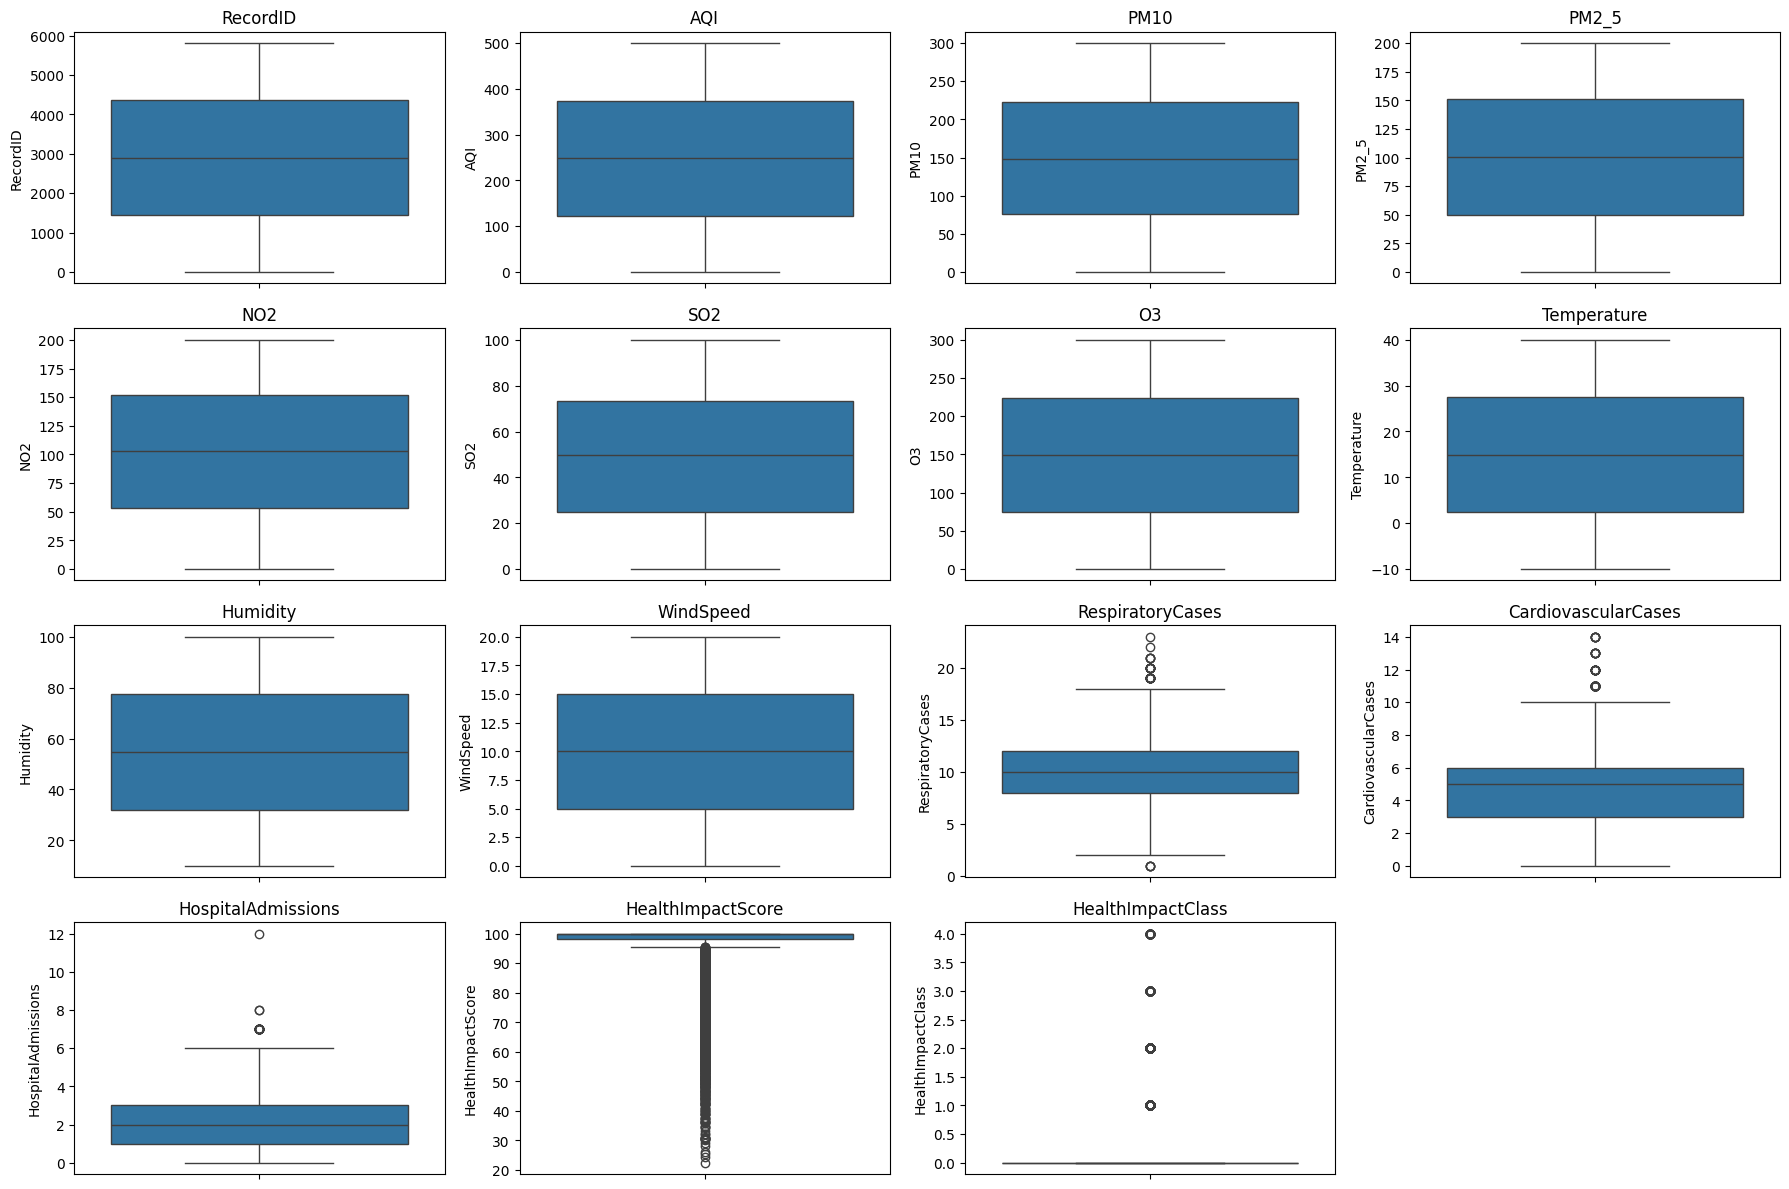

In [17]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(18,12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

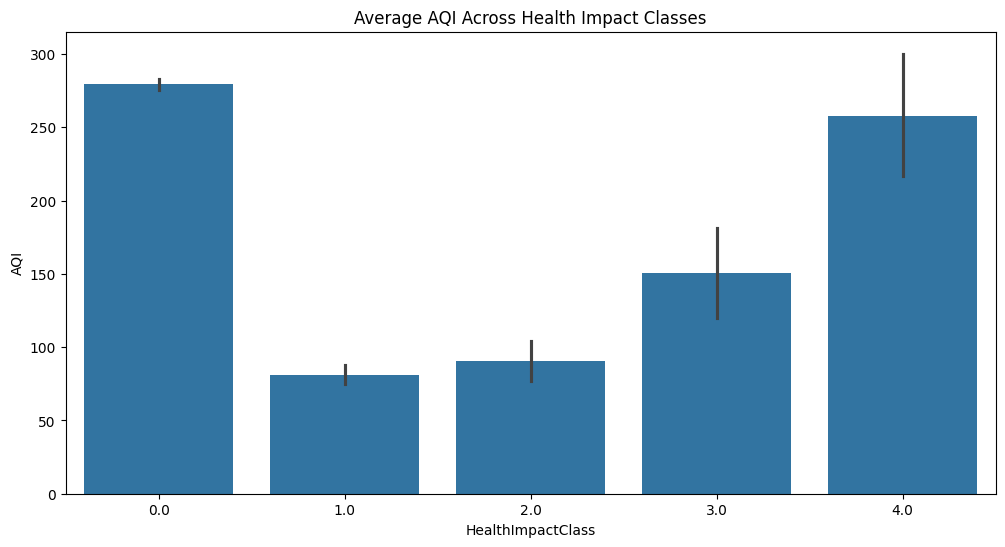

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='HealthImpactClass',
    y='AQI'
)

plt.title("Average AQI Across Health Impact Classes")
plt.show()

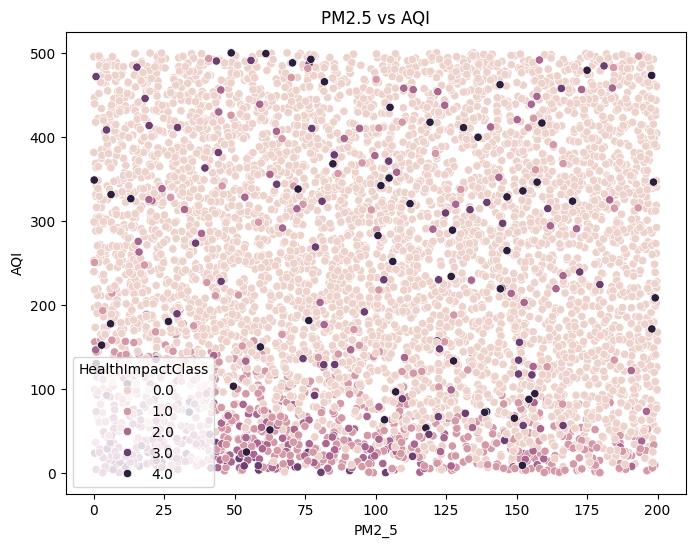

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='PM2_5',
    y='AQI',
    hue='HealthImpactClass'
)

plt.title("PM2.5 vs AQI")
plt.show()

Feature Engineering

In [20]:
# Drop unnecessary columns
df = df.drop(columns=['RecordID', 'HealthImpactScore'])

In [21]:
# Features
X = df.drop(columns='HealthImpactClass')

# Target
y = df['HealthImpactClass']

In [22]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (5811, 12)
Target Shape: (5811,)


In [23]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

In [24]:
X = pd.get_dummies(X, drop_first=True)

## Splitting the Dataset

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [26]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4648, 12)
X_test : (1163, 12)
y_train: (4648,)
y_test : (1163,)


In [27]:
## Feature Scaling
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [28]:
print("Scaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape:", X_test_scaled.shape)

Scaled Training Data Shape: (4648, 12)
Scaled Testing Data Shape: (1163, 12)


## Model Building

In [29]:
## Create a Function to Evaluate Models
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

In [30]:
## Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_accuracy = evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

Logistic Regression Accuracy: 0.8745


In [31]:
## Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

dt_accuracy = evaluate_model(dt_model,X_train,X_test,y_train,y_test)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.8375


In [32]:
## Train Random Forest
rf_model = RandomForestClassifier(random_state=42)

rf_accuracy = evaluate_model(rf_model,X_train,X_test,y_train,y_test)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8977


In [33]:
## Train K-Nearest Neighbors
knn_model = KNeighborsClassifier()

knn_accuracy = evaluate_model(knn_model,X_train_scaled,X_test_scaled,y_train,y_test)

print(f"KNN Accuracy: {knn_accuracy:.4f}")

KNN Accuracy: 0.8435


In [34]:
## Train Support Vector Machine
svm_model = SVC(random_state=42)

svm_accuracy = evaluate_model(svm_model,X_train_scaled,X_test_scaled,y_train,y_test)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.8994


In [35]:
## Train Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)

gb_accuracy = evaluate_model(gb_model,X_train,X_test,y_train,y_test)

print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")

Gradient Boosting Accuracy: 0.8968


In [36]:
## Compare Model Performance
model_results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","KNN","SVM","Gradient Boosting"],
    "Accuracy": [lr_accuracy,dt_accuracy,rf_accuracy,knn_accuracy,svm_accuracy,gb_accuracy]
})

model_results = model_results.sort_values(
    by="Accuracy",
    ascending=False
)

model_results.reset_index(drop=True, inplace=True)

model_results

,Model,Accuracy
0,SVM,0.899398
1,Random Forest,0.897678
2,Gradient Boosting,0.896819
3,Logistic Regression,0.874463
4,KNN,0.843508
5,Decision Tree,0.837489


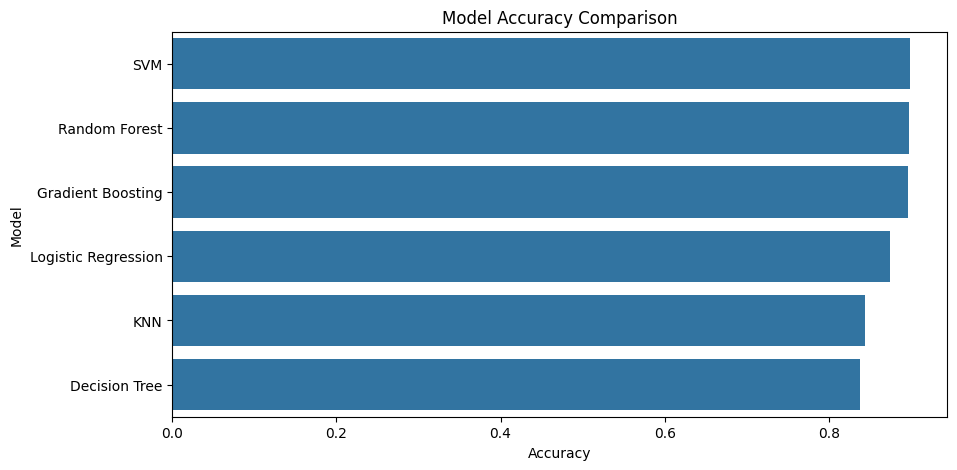

In [37]:
## Visualize Model Comparison
plt.figure(figsize=(10,5))

sns.barplot(data=model_results,x="Accuracy",y="Model")

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.show()

In [38]:
## SVM has the highest accuracy

## Model Evaluation

In [39]:
## Make predictions on the test data
y_pred = svm_model.predict(X_test_scaled)

In [40]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy Score: {accuracy:.4f}")

Accuracy Score: 0.8994


In [41]:
# Precision, Recall and F1-Score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.8671
Recall    : 0.8994
F1 Score  : 0.8810


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97       962
         1.0       0.63      0.68      0.66       116
         2.0       0.48      0.25      0.33        55
         3.0       0.00      0.00      0.00        19
         4.0       0.00      0.00      0.00        11

    accuracy                           0.90      1163
   macro avg       0.41      0.39      0.39      1163
weighted avg       0.87      0.90      0.88      1163



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


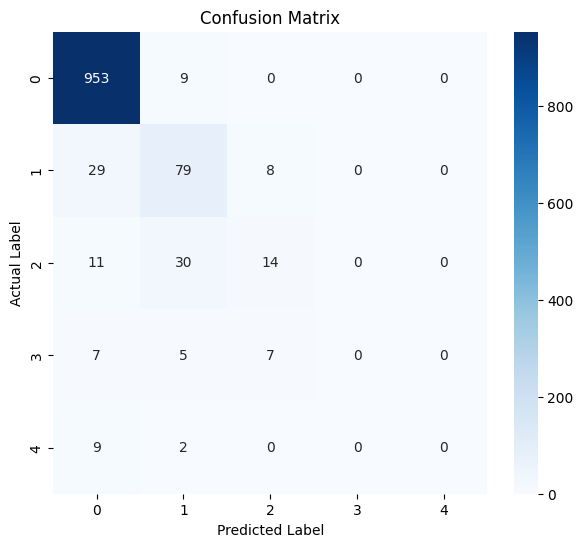

In [43]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [44]:
## Cross-Validation Score
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(SVC(random_state=42),X_train_scaled,y_train,cv=5,scoring='accuracy',n_jobs=-1)

print("Cross Validation Scores:")
print(cv_scores)

print(f"\nMean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross Validation Scores:
[0.89354839 0.89354839 0.90322581 0.88697524 0.89666308]

Mean CV Accuracy: 0.8948
Standard Deviation: 0.0053


In [45]:
## Summary Table
evaluation_results = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1 Score","Mean Cross Validation Accuracy"],
    "Score": [accuracy,precision,recall,f1,cv_scores.mean()]
})

evaluation_results

,Metric,Score
0,Accuracy,0.899398
1,Precision,0.867130
2,Recall,0.899398
3,F1 Score,0.881047
4,Mean Cross Validation Accuracy,0.894792


## Hyperparameter Tuning

In [46]:
## Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

In [47]:
## Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=SVC(probability=True,random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [48]:
## Train the Model
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.01, 0.1],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy', verbose=2)

In [49]:
## Display the Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


In [50]:
## Best Cross-Validation Score
print(f"Best Cross Validation Accuracy: {grid_search.best_score_:.4f}")

Best Cross Validation Accuracy: 0.9178


In [51]:
## Retrieve the Best Model
best_model = grid_search.best_estimator_

In [52]:
## Evaluate the Tuned Model
y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Tuned Model Accuracy: {accuracy:.4f}")

Tuned Model Accuracy: 0.9175


In [53]:
## Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97       962
         1.0       0.79      0.72      0.75       116
         2.0       0.62      0.56      0.59        55
         3.0       0.00      0.00      0.00        19
         4.0       0.00      0.00      0.00        11

    accuracy                           0.92      1163
   macro avg       0.47      0.45      0.46      1163
weighted avg       0.89      0.92      0.90      1163



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


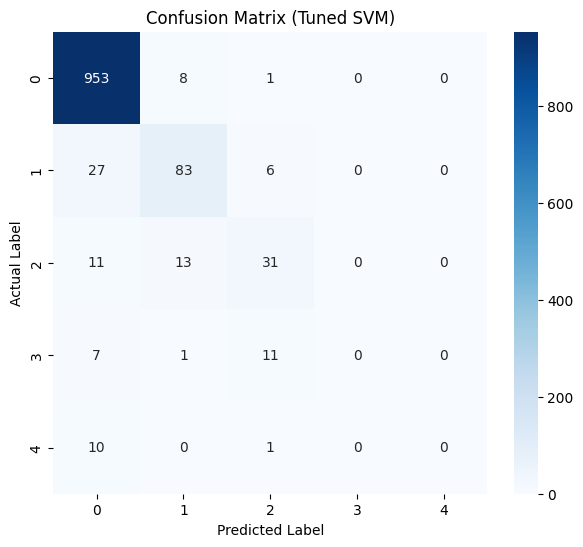

In [54]:
## Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix (Tuned SVM)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [55]:
## Compare Before vs After Tuning
comparison = pd.DataFrame({
    "Model": ["Baseline SVM","Tuned SVM"],
    "Accuracy": [svm_accuracy,accuracy]})

comparison

,Model,Accuracy
0,Baseline SVM,0.899398
1,Tuned SVM,0.917455


## Model Serialization

In [56]:
import pickle

In [60]:
## Save the Trained Mode
with open("air_quality_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

In [61]:
#$ Save the fitted StandardScaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [62]:
# Save feature names
feature_names = X.columns.tolist()

with open("feature_names.pkl", "wb") as file:
    pickle.dump(feature_names, file)

In [63]:
## Verify the Saved Files

# Load the saved model
with open("air_quality_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# Load the scaler
with open("scaler.pkl", "rb") as file:
    loaded_scaler = pickle.load(file)

# Load feature names
with open("feature_names.pkl", "rb") as file:
    loaded_features = pickle.load(file)

In [64]:
# Scale sample data
sample_data = loaded_scaler.transform(X_test.iloc[:5])

# Make predictions
predictions = loaded_model.predict(sample_data)

print("Predicted Classes:")
print(predictions)

print("\nActual Classes:")
print(y_test.iloc[:5].values)

Predicted Classes:
[0. 0. 0. 2. 0.]

Actual Classes:
[0. 0. 0. 2. 0.]


In [65]:
from google.colab import files

files.download("air_quality_model.pkl")
files.download("scaler.pkl")
files.download("feature_names.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>